In [20]:
from pymatgen.io.vasp import Vasprun

# 1. Load VASP result (vasprun.xml)
v_pure = Vasprun("vasprun_TiO2.xml", parse_dos=True, parse_eigen=True)
v_doped = Vasprun("vasprun_PTiO2.xml", parse_dos=True, parse_eigen=True)

In [58]:
#test

# 1. Complete DOS 객체 얻기 (PDOS 포함)
cdos = v_pure.complete_dos

# 2. CBM, VBM 및 Band gap 얻기 (DOS 기준)
cbm, vbm = cdos.get_cbm_vbm()
gap_info = cdos.get_gap()

print(f"DOS 기준 VBM: {vbm} eV")
print(f"DOS 기준 CBM: {cbm} eV")
print(f"DOS 기준 Band Gap: {gap_info} eV")

DOS 기준 VBM: 3.1268906412915736 eV
DOS 기준 CBM: 5.124426397086765 eV
DOS 기준 Band Gap: 1.9975357557951914 eV


In [ ]:
from pymatgen.electronic_structure.core import Spin, Orbital
from pymatgen.electronic_structure.bandstructure import BandStructure
import numpy as np

def get_pdos(vasprun_obj):
    cdos = vasprun_obj.complete_dos
    efermi = cdos.efermi
    energies = cdos.energies - efermi

    # Band gap 계산
    cbm, vbm = cdos.get_cbm_vbm()
    band_gap = cdos.get_gap()

    # 1. Total DOS Preparation
    total_up = cdos.get_densities(Spin.up)
    total_down = np.zeros_like(total_up)
    if Spin.down in cdos.densities:
        total_down = cdos.get_densities(Spin.down)
    total_dos = total_up + total_down

    # 2. PDOS Preparation
    p_indices = [i for i, site in enumerate(vasprun_obj.final_structure) if site.specie.symbol == "P"]
    o_indices = [i for i, site in enumerate(vasprun_obj.final_structure) if site.specie.symbol == "O"]
    ti_indices = [i for i, site in enumerate(vasprun_obj.final_structure) if site.specie.symbol == "Ti"]

    indices = {'p_indices' : p_indices, 'o_indices' : o_indices, 'ti_indices' : ti_indices}

    target_orbitals = {
        'p_indices' : [Orbital.px, Orbital.py, Orbital.pz],
        'o_indices' : [Orbital.px, Orbital.py, Orbital.pz],
        'ti_indices' : [Orbital.dxy, Orbital.dyz, Orbital.dxz, Orbital.dz2, Orbital.dx2]
    }

    results = {}


    # 3. PDOS Summation
    for atom_type, index_list in indices.items() : 
        if not index_list :
            continue

        orbs_to_sum = target_orbitals.get(atom_type, [])

        sum_up = np.zeros_like(energies)
        sum_down = np.zeros_like(energies)

        for idx in index_list:
            site = vasprun_obj.final_structure[idx]
            site_orb_dos = cdos.pdos[site]

            for orb in orbs_to_sum:
                if orb in site_orb_dos:
                    sum_up += site_orb_dos[orb][Spin.up]
                    if Spin.down in site_orb_dos[orb]:
                        sum_down += site_orb_dos[orb][Spin.down]
        
        results[atom_type] = {

            'sum_up': sum_up,
            'sum_down' : sum_down,
        }


    results['total'] = {
    'energies': energies, 'efermi': efermi,
    'sum_up': total_up, 'sum_down': total_down,
    'band_gap': band_gap, 'vbm': vbm, 'cbm': cbm
    }

    return results


data_pure = get_pdos(v_pure)  
data_doped = get_pdos(v_doped)

In [60]:
print (data_pure.keys())

dict_keys(['o_indices', 'ti_indices', 'total'])


In [61]:
def plot_pdos(results, save_name):
    plt.figure(figsize=(8, 5))
    
    total_data = results.get('total', {})
    energies = total_data.get('energies')

    #Total DOS bavkground
    if 'total' in results:
        plt.plot(energies, results['total']['sum_up'], color='black', label='Total DOS', lw=1.8)
        plt.plot(energies, -results['total']['sum_down'], color='black', lw=1.8)

    if 'band_gap' in total_data:
        gap = total_data['band_gap']
        plt.text(0.95, 0.05, f"Band Gap: {gap:.3f} eV", 
                 transform=plt.gca().transAxes, ha='right', fontsize=12, 
                 fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))

    # 3. 원소별 PDOS 그리기 (기존 로직)
    style_map = {
        'p_indices':  {'color': '#2CA02C', 'label': 'P_3p'},
        'o_indices':  {'color': '#FF0000', 'label': 'O_2p'},
        'ti_indices': {'color': '#0022FF', 'label': 'Ti_3d'},
        'ni_indices': {'color': '#0022FF', 'label': 'Ni_3d'},
        'fe_indices': {'color': '#D343FF', 'label': 'Fe_3d'},
    }

    for atom_key, data in results.items():
        if atom_key == 'total': continue # Total pass
        
        style = style_map.get(atom_key, {'color': None, 'label': atom_key})
        plt.plot(energies, data['sum_up'], color=style['color'], label=style['label'], lw=1.8)
        plt.plot(energies, -data['sum_down'], color=style['color'], lw=1.8)

    # 4. 스타일링 및 저장
    plt.axvline(0, color='black', linestyle='--', lw=1.5)
    plt.xlim(-10, 6)
    plt.ylim(-75, 75)
    plt.xlabel('Energy ($\mathbf{E - E_F}$, eV)', fontsize=14, fontweight='bold')
    plt.ylabel('PDOS (states/eV)', fontsize=14, fontweight='bold')
    plt.legend(frameon=False, fontsize=11, loc='upper right')

    ax = plt.gca()
    for spine in ax.spines.values(): spine.set_linewidth(2.0)
    ax.tick_params(width=2.0, length=6, labelsize=12)
    for label in ax.get_xticklabels() + ax.get_yticklabels(): label.set_fontweight('bold')

    plt.tight_layout()
    plt.savefig(save_name, dpi=300)
    print(f"Saved: {save_name}")
    plt.show()

<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_48395/39971784.py:38: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Energy ($\mathbf{E - E_F}$, eV)', fontsize=14, fontweight='bold')


Saved: PDOS_TiO2.png


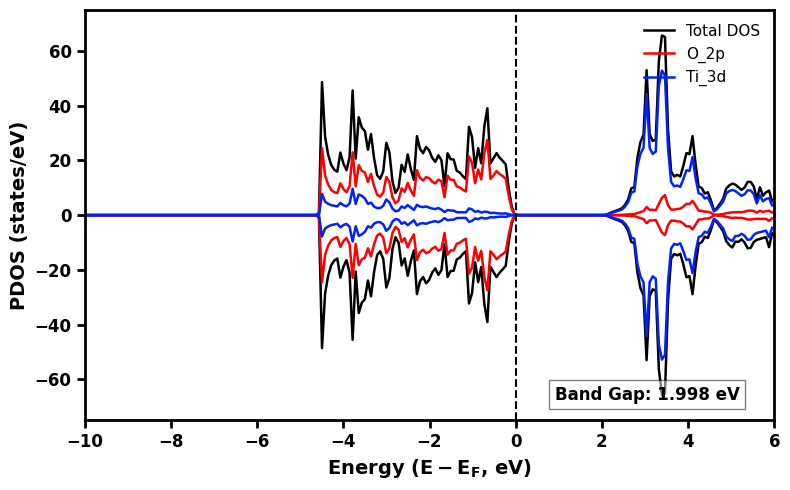

In [62]:
plot_pdos(data_pure, "PDOS_TiO2.png")

Saved: PDOS_PTiO2.png


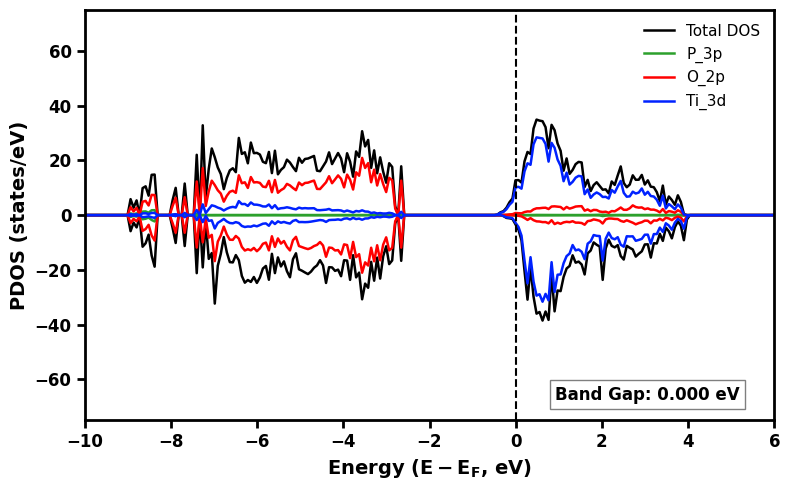

In [64]:
plot_pdos(data_doped, "PDOS_PTiO2.png")